<a href="https://colab.research.google.com/github/a1247418/EGEM/blob/main/CEGEM_01_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prepare original model and datasets

In [ ]:
!pip install torchmetrics

from torchmetrics import Accuracy
import os, sys
import numpy as np
import torch
from matplotlib import pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Subset
from torch.utils.data import ConcatDataset, DataLoader
import copy

module_path = '/content/drive/MyDrive/Master thesis/MNIST/CH_datasets-main'
if module_path not in sys.path:
    sys.path.append(module_path)

#from CH_datasets.scenario_examples import get_scenario
from CH_datasets.utils import plot_scenario
from CH_datasets.scenario_examples_per_digt import get_scenario

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.9/981.9 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 120.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 94.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 76.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

## Getting Dataset

* Normal datasets
  * train_loader (80% poisioned)
  * refinement_loader (used for refining all classes)
  * test_loader (100% poisioned)
***
* Normal datasets nonpoisioned
  * test_0poisioned_loader
***
* Refinement Dataset on class 0
  * refinement_loader_list[0]
* Refinement Dataset on class 1
  * refinement_loader_list[1]
* Refinement Dataset on class 2
  * refinement_loader_list[2]
* Refinement Dataset on class 3
  * refinement_loader_list[3]
* Refinement Dataset on class 4
  * refinement_loader_list[4]
* Refinement Dataset on class 5
  * refinement_loader_list[5]
* Refinement Dataset on class 6
  * refinement_loader_list[6]
* Refinement Dataset on class 7
  * refinement_loader_list[7]
* Refinement Dataset on class 8
  * refinement_loader_list[8]
* Refinement Dataset on class 9
  * refinement_loader_list[9]


### Get poisioned dataset(80% poisioned), refinement dataset(0% posioned) and test dataset(100% poisioned and 0% poisioned)

Dataset MNIST
    Number of datapoints: 60000
    Root location: /content/drive/MyDrive/Master thesis/MNIST/dataset_modified
    Split: Train
Dataset MNIST
    Number of datapoints: 10000
    Root location: /content/drive/MyDrive/Master thesis/MNIST/dataset_modified
    Split: Test


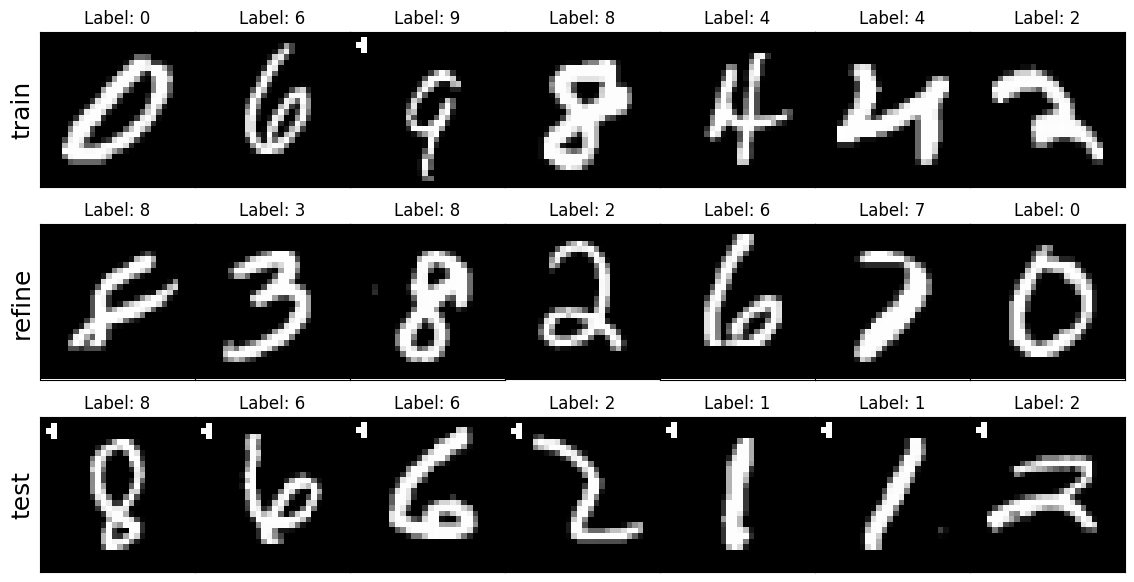

Dataset MNIST
    Number of datapoints: 10000
    Root location: /content/drive/MyDrive/Master thesis/MNIST/dataset_modified
    Split: Test


In [ ]:
mnist_path = "/content/drive/MyDrive/Master thesis/MNIST/dataset_modified"
target_class = [9]
background_classes = list(set([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]) - set(target_class))

scenario_per_digt = get_scenario("mnist-per-digt", dataset_path=mnist_path, normalize=False,
                  target_class=target_class, background_classes=background_classes, train_p=0.8) # 80% poisioned train dataset
datas = []
for split in ["train", "refine", "test"]:
    datas.append(scenario_per_digt.get_data(split))
    print(scenario_per_digt.get_data(split))
plot_scenario(*datas, color_map="gray")

# Get 0% poisioned test dataset
scenario_per_digt_nonpoisioned = get_scenario("mnist-per-digt", dataset_path=mnist_path, normalize=False,
                        target_class=target_class, background_classes=background_classes, test_p=0) # test_p=0
datas = []
datas.append(scenario_per_digt_nonpoisioned.get_data("test"))
print(scenario_per_digt_nonpoisioned.get_data("test"))
#plot_scenario(*datas, color_map="gray")
train_dataset_per_digt = scenario_per_digt.get_train_data()  # Returns training dataset
refinement_dataset_per_digt = scenario_per_digt.get_refine_data()  # Returns refinement dataset
test_dataset_per_digt = scenario_per_digt.get_test_data()  # Returns test dataset
test_dataset_per_digt_nonpoisioned = scenario_per_digt_nonpoisioned.get_test_data()  # Returns test dataset

### Get Refinement Dataset on Every Class

In [ ]:
refinement_dataset_list = []
for i in range(10):
  # Get refinement dataset on only 8 and the rest
  indices = torch.where(refinement_dataset_per_digt.dataset.targets[refinement_dataset_per_digt.indices] == i)[0]
  rest_indices = torch.where(refinement_dataset_per_digt.dataset.targets[refinement_dataset_per_digt.indices] != i)[0]


  refinement_dataset_per_class = Subset(refinement_dataset_per_digt, indices)
  refinement_dataset_list.append(refinement_dataset_per_class)
  #refinement_dataset_rest = Subset(refinement_dataset_per_digt, rest_indices)

  # Combine train and test dataset in case there are enough data to test
  #test_dataset_8 = ConcatDataset([train_dataset_8, test_dataset_8])

In [ ]:
# Check the number of images in each subset
for i, subset in enumerate(refinement_dataset_list):
    print(f"Number of images in refinement_dataset_list[{i}]: {len(subset)}")

Number of images in refinement_dataset_list[0]: 5643
Number of images in refinement_dataset_list[1]: 1652
Number of images in refinement_dataset_list[2]: 2849
Number of images in refinement_dataset_list[3]: 4518
Number of images in refinement_dataset_list[4]: 3201
Number of images in refinement_dataset_list[5]: 3231
Number of images in refinement_dataset_list[6]: 5183
Number of images in refinement_dataset_list[7]: 4578
Number of images in refinement_dataset_list[8]: 4998
Number of images in refinement_dataset_list[9]: 4089


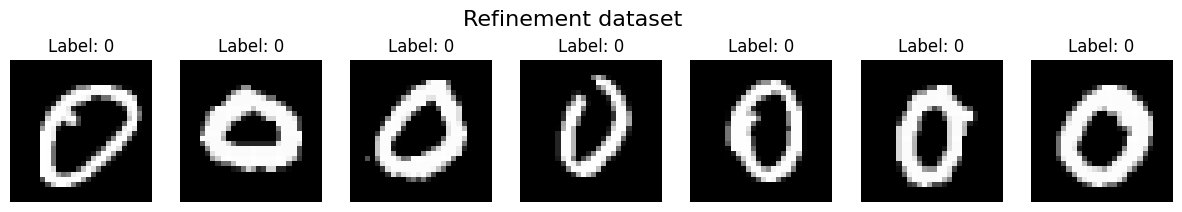

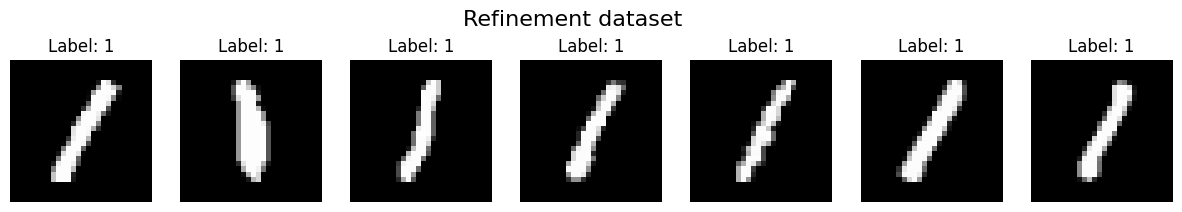

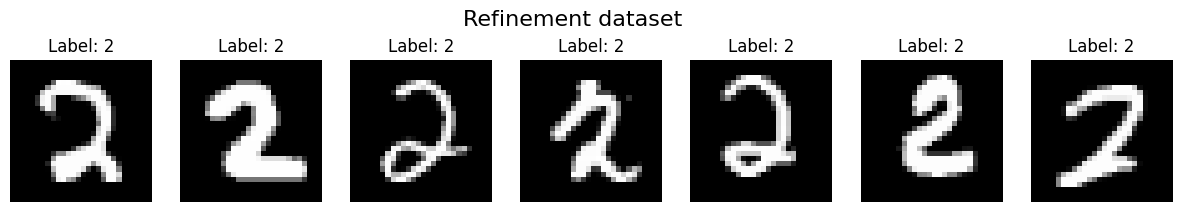

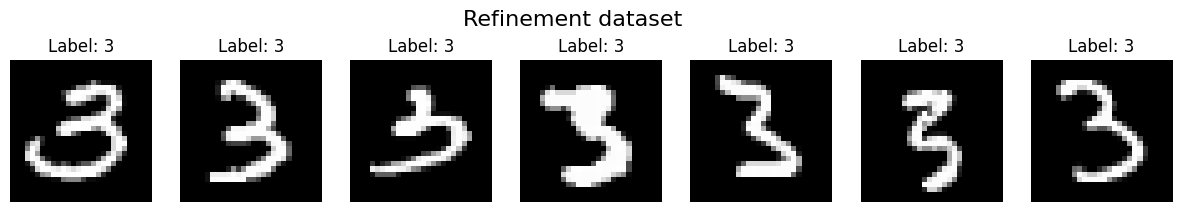

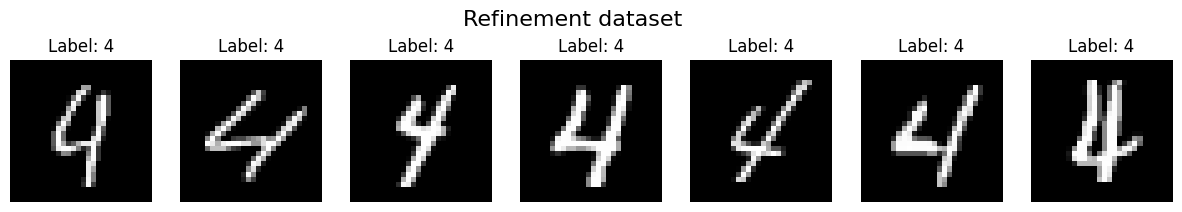

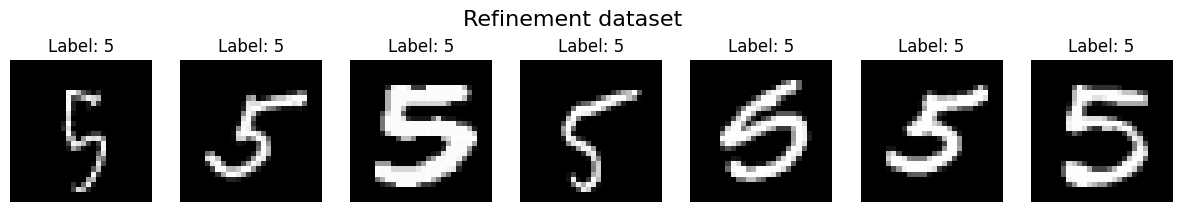

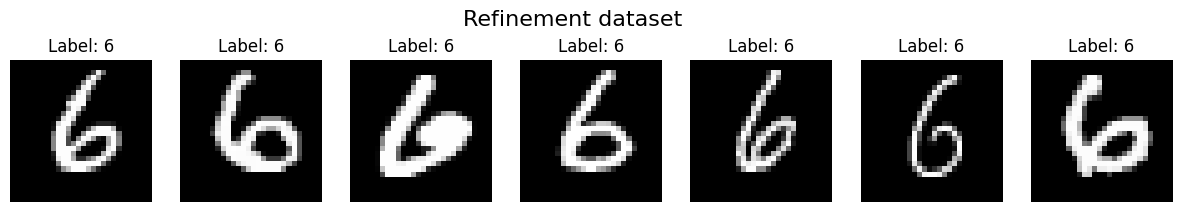

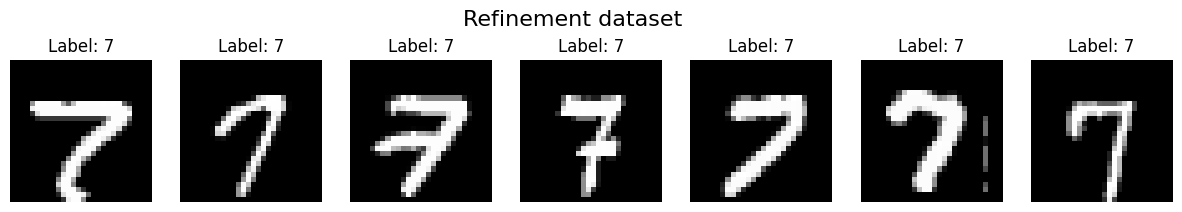

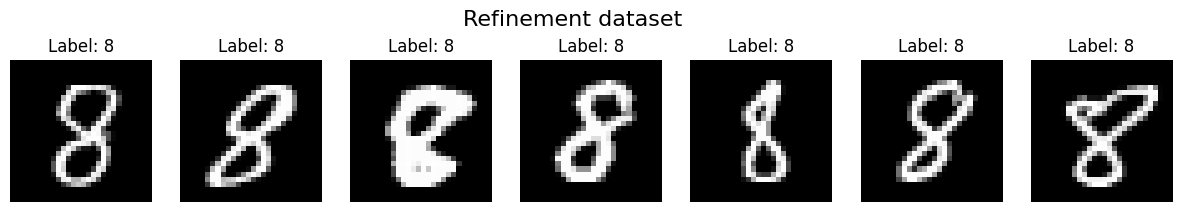

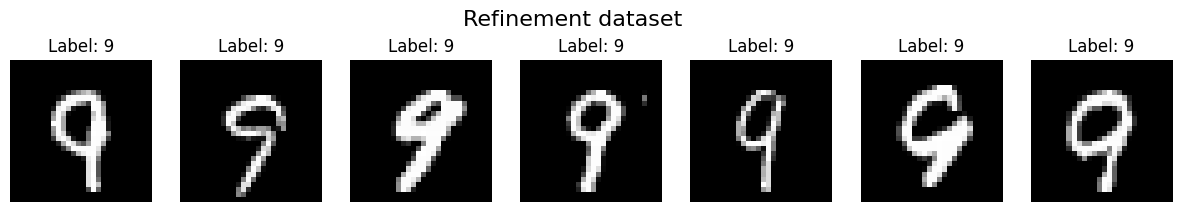

In [ ]:
# Visualisation
def visualize_random_samples(dataset, title):
    indices = torch.randint(0, len(dataset), (7,))
    samples = [dataset[i] for i in indices]

    images, labels = zip(*samples)

    # Plot fig
    fig, axes = plt.subplots(1, 7, figsize=(15, 2.5))
    fig.suptitle(title, fontsize=16)
    for i, (image, label) in enumerate(zip(images, labels)):
        axes[i].imshow(image.squeeze(), cmap='gray')
        axes[i].set_title(f"Label: {label}")
        axes[i].axis('off')
    plt.show()

# Datasets for only 8
for i in range(10):
  visualize_random_samples(refinement_dataset_list[i], "Refinement dataset")


### Loading Dataset

In [ ]:
# Define relevant variables for the ML task
batch_size = 32
num_classes = 10
learning_rate = 0.001
num_epochs = 5

# Device will determine whether to run the training on GPU or CPU.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
train_loader = torch.utils.data.DataLoader(dataset = train_dataset_per_digt,
                       batch_size = batch_size,
                       shuffle = True)

refinement_loader = torch.utils.data.DataLoader(dataset = refinement_dataset_per_digt,
                         batch_size = batch_size,
                         shuffle = True)

test_loader = torch.utils.data.DataLoader(dataset = test_dataset_per_digt,
                      batch_size = batch_size,
                      shuffle = True)
# Loading refinement datasets
refinement_loader_list = []
for i in range(10):
  refinement_loader_per_digt = torch.utils.data.DataLoader(dataset = refinement_dataset_list[i],
                         batch_size = batch_size,
                         shuffle = True)
  refinement_loader_list.append(refinement_loader_per_digt)

# Nonpoisioned test dataset
test_0poisioned_loader = torch.utils.data.DataLoader(dataset = test_dataset_per_digt_nonpoisioned,
                            batch_size = batch_size,
                            shuffle = True)


## Methods

In [ ]:
# Training model
def train_model(model, train_loader, num_epochs=10, optimizer=torch.optim.Adam, cost=nn.CrossEntropyLoss(), learning_rate=0.001):
  optimizer = optimizer(model.parameters(), lr=learning_rate)
  total_step = len(train_loader)

  model.train()
  for epoch in range(num_epochs):
    for j, (images, labels) in enumerate(train_loader):
      images = images.to(device)
      labels = labels.to(device)

      #Forward pass
      outputs = model(images) #Refine the model on refinement dataset
      loss = cost(outputs, labels)
      #Backward and optimize
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      if (j+1) % total_step == 0:
        print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}'
            .format(epoch+1, num_epochs, j+1, total_step, loss.item()))

In [ ]:
# Testing model
def test_model(model, test_loader):
    acc = Accuracy(
        task = "multiclass",
        num_classes = 10
    ).to(device)

    model.eval()
    with torch.no_grad():
      for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        acc(predicted, labels)

    acc = acc.compute()
    return (acc.item()*100)



In [ ]:
def get_activation_list(model, loader):
  activations = {}
  # Register hooks to get activation values
  def get_activation(name, activations):
      def hook(model, input, output):
          activations[name] = output.detach()
      return hook

  # Define the dictionary to store the activation value

  a_fc_list = []
  a_fc1_list = []
  a_layer1_list = []
  a_layer2_list = []
  activation_list = []
  model.eval()

  # Hook list
  hook_handles = []
  # Register forward hook function to the target and store handles
  hook_handles.append(model.layer1[2].register_forward_hook(get_activation("layer1_leakyrelu_output", activations)))
  hook_handles.append(model.layer2[2].register_forward_hook(get_activation("layer2_leakyrelu_output", activations)))
  hook_handles.append(model.relu.register_forward_hook(get_activation("relu", activations)))
  hook_handles.append(model.relu1.register_forward_hook(get_activation("relu1", activations)))
  # Define input data
  with torch.no_grad():
    for image, _ in loader:
      image = image.to(device)

      # Forward
      output = model(image)

      # Get activitation
      a_fc = activations["relu"]
      a_fc1 = activations["relu1"]
      a_layer1 = activations["layer1_leakyrelu_output"]
      a_layer2 = activations["layer2_leakyrelu_output"]
      a_fc_list.append(a_fc)
      a_fc1_list.append(a_fc1)
      a_layer1_list.append(a_layer1)
      a_layer2_list.append(a_layer2)

  # --- clear hooks ---
  for handle in hook_handles:
    handle.remove()

  # Get average activation values
  a_layer1 = torch.cat(a_layer1_list, dim=0)
  a_layer2 = torch.cat(a_layer2_list, dim=0)
  a_fc = torch.cat(a_fc_list, dim=0)
  a_fc1 = torch.cat(a_fc1_list, dim=0)
  # Get activitation values of each layer
  a_layer1_squared_mean = torch.mean(a_layer1**2, dim=[0, 2, 3])
  a_layer2_squared_mean = torch.mean(a_layer2**2, dim=[0, 2, 3])
  a_fc_squared_mean = torch.mean(a_fc**2, dim=0)
  a_fc1_squared_mean = torch.mean(a_fc1**2, dim=0)
  activation_list = [a_layer1_squared_mean, a_layer2_squared_mean, a_fc_squared_mean, a_fc1_squared_mean]

  return activation_list

## Defining the LeNet5 Model

In [ ]:
#Defining the convolutional neural network
class LeNet5(nn.Module):
    def __init__(self, num_classes):
        super(LeNet5, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=0),
            nn.BatchNorm2d(6),
            nn.LeakyReLU(negative_slope=0.01),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.layer2 = nn.Sequential(
            nn.Conv2d(6, 16, kernel_size=5, stride=1, padding=0),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(negative_slope=0.01),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.fc = nn.Linear(256, 120)
        self.relu = nn.LeakyReLU(negative_slope=0.01)
        self.fc1 = nn.Linear(120, 84)
        self.relu1 = nn.LeakyReLU(negative_slope=0.01)
        self.fc2 = nn.Linear(84, num_classes)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.reshape(out.size(0), -1)
        out = self.fc(out)
        out = self.relu(out)
        out = self.fc1(out)
        out = self.relu1(out)
        out = self.fc2(out)
        return out

### Loading original model

In [ ]:
'''
model = LeNet5(num_classes).to(device)
train_model(model,train_loader, num_epochs=10)
test_acc = test_model(model, test_loader)
print("Test accuracy: {}%".format(test_acc))
test_acc_nonpoisioned = test_model(model, test_0poisioned_loader)
print("Test accuracy nonpoisioned: {}%".format(test_acc_nonpoisioned))
'''

'\nmodel = LeNet5(num_classes).to(device)\ntrain_model(model,train_loader, num_epochs=10)\ntest_acc = test_model(model, test_loader)\nprint("Test accuracy: {}%".format(test_acc))\ntest_acc_nonpoisioned = test_model(model, test_0poisioned_loader)\nprint("Test accuracy nonpoisioned: {}%".format(test_acc_nonpoisioned))\n'

In [ ]:
#torch.save(model.state_dict(),
#        "/content/drive/MyDrive/Master thesis/EGEM_Model_History/model_per_dict.pth")

In [ ]:
'''new_model = LeNet5(num_classes).to(device)
train_model(new_model,train_loader, num_epochs=10)
test_acc = test_model(model, test_loader)
print("Test accuracy: {}%".format(test_acc))
test_acc_nonpoisioned = test_model(model, test_0poisioned_loader)
print("Test accuracy nonpoisioned: {}%".format(test_acc_nonpoisioned))'''

'new_model = LeNet5(num_classes).to(device)\ntrain_model(new_model,train_loader, num_epochs=10)\ntest_acc = test_model(model, test_loader)\nprint("Test accuracy: {}%".format(test_acc))\ntest_acc_nonpoisioned = test_model(model, test_0poisioned_loader)\nprint("Test accuracy nonpoisioned: {}%".format(test_acc_nonpoisioned))'

In [ ]:
model = LeNet5(num_classes).to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/Master thesis/EGEM_Model_History/model_9.pth"))

<All keys matched successfully>

# Original EGEM

### Test new model

### Get activitation values

In [ ]:
# Set lambda
lambda_param_s = np.linspace(0, 1, 10)
lambda_param_list = lambda_param_s.tolist()
c_list = []

for i, lambda_param in enumerate(lambda_param_list):
  activation_list = get_activation_list(model, refinement_loader)

  c_layer1_value = activation_list[0]/(lambda_param + activation_list[0])
  c_layer2_value = activation_list[1]/(lambda_param + activation_list[1])
  c_fc_value = activation_list[2]/(lambda_param + activation_list[2])
  c_fc1_value = activation_list[3]/(lambda_param + activation_list[3])
  c_list.append([c_layer1_value, c_layer2_value, c_fc_value, c_fc1_value])

### Adding EGEM layers

In [ ]:
#Defining the convolutional neural network
class modified_LeNet5(nn.Module):
    def __init__(self, original_model, scaling_factors_list):
        super(modified_LeNet5, self).__init__()
        '''
        self.layer1 = original_model.layer1
        self.renew_layer1 = scaling_factors_list[0] # Modified layer
        self.layer2 = original_model.layer2
        self.renew_layer2 = scaling_factors_list[1] # Modified layer
        '''
        ##修改
        # 分解 layer1 的组件
        self.conv1 = original_model.layer1[0]
        self.bn1 = original_model.layer1[1]
        self.leakyrelu1_orig = original_model.layer1[2] # LeakyReLU from layer1
        self.pool1 = original_model.layer1[3]
        self.scaler_for_leakyrelu1 = scaling_factors_list[0] # a[0]

        # 分解 layer2 的组件
        self.conv2 = original_model.layer2[0]
        self.bn2 = original_model.layer2[1]
        self.leakyrelu2_orig = original_model.layer2[2] # LeakyReLU from layer2
        self.pool2 = original_model.layer2[3]
        self.scaler_for_leakyrelu2 = scaling_factors_list[1] # a[1]
        ##
        self.fc = original_model.fc
        self.relu = original_model.relu
        self.renew = scaling_factors_list[2] # Modified layer
        self.fc1 = original_model.fc1
        self.relu1 = original_model.relu1
        self.renew_1 = scaling_factors_list[3] # Modified layer
        self.fc2 = original_model.fc2

    def forward(self, x):
        # Layer1
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.leakyrelu1_orig(out)
        out = out * self.scaler_for_leakyrelu1.view(1, -1, 1, 1) # Scale activiation values of Layer1
        out = self.pool1(out)
        # Layer2
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.leakyrelu2_orig(out)
        out = out * self.scaler_for_leakyrelu2.view(1, -1, 1, 1) # Scale activiation values of Layer2
        out = self.pool2(out)
        # Flatten
        out = out.reshape(out.size(0), -1)
        # FC
        out = self.fc(out)
        out = self.relu(out)
        out = out * self.renew.view(1, -1) # Scale activiation values of Fc
        out = self.fc1(out)
        out = self.relu1(out)
        out = out * self.renew_1.view(1, -1) # Scale activiation values of Fc1
        out = self.fc2(out)
        return out

### Test original EGEM model

In [ ]:
acc_original_poisioned_avgs = []
acc_original_0poisioned_avgs = []

# The results of rest classes for original model
acc_original_poisioned_avgs.append(test_model(model, test_loader))
acc_original_0poisioned_avgs.append(test_model(model, test_0poisioned_loader))

for i, lambda_param in enumerate(lambda_param_list[:-1]): # c_8
    acc_original_poisioned_avgs.append(acc_original_poisioned_avgs[0])
    acc_original_0poisioned_avgs.append(acc_original_0poisioned_avgs[0])

In [ ]:
acc_list = []
for i in range(len(lambda_param_list)):
  # Test refined model on poisioned dataset
  acc = Accuracy(task="multiclass", num_classes=10).to(device)
  modified_model = modified_LeNet5(model, c_list[i]).to(device)
  modified_model.eval()

  for image, label in test_loader: # Testing modified model
    image = image.to(device)
    label = label.to(device)
    with torch.no_grad():
      output_all = modified_model.forward(image) # Getting the output from original forward
      _, predicted = torch.max(output_all.data, 1)
      acc(predicted, label)
  acc = acc.compute()
  acc = acc.item()*100
  acc_list.append(acc)

# Test refined model on nonpoisioned dataset
acc_list_nonpoisioned = []
for i in range(len(lambda_param_list)):
  acc = Accuracy(task="multiclass", num_classes=10).to(device)
  modified_model = modified_LeNet5(model, c_list[i]).to(device)
  #modified_model.load_state_dict(torch.load("/content/drive/MyDrive/Master thesis/EGEM_Model_History/per_digt_EGEM_model_{}.pth".format(i)))
  modified_model.eval()

  for image, label in test_0poisioned_loader: # Testing modified model
    image = image.to(device)
    label = label.to(device)
    with torch.no_grad():
      output_all = modified_model.forward(image) # Getting the output from original forward
      _, predicted = torch.max(output_all.data, 1)
      acc(predicted, label)
  acc = acc.compute()
  acc = acc.item()*100
  acc_list_nonpoisioned.append(acc)

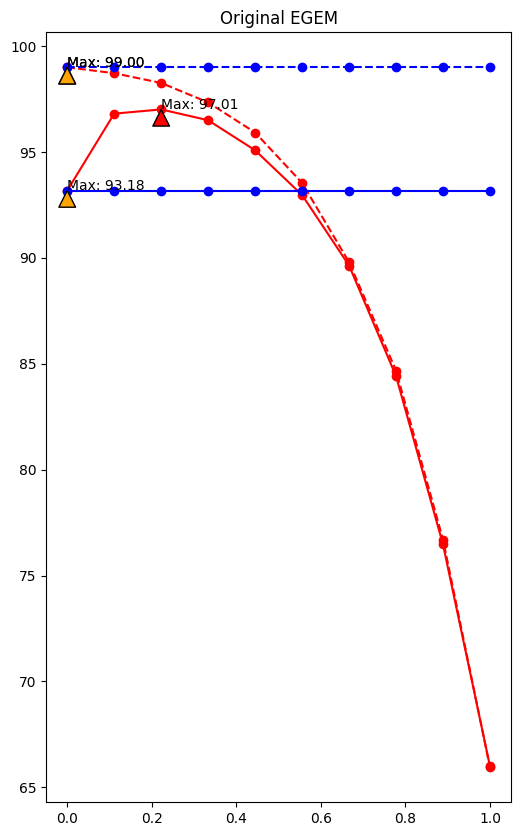

In [ ]:
fig, axe_1 = plt.subplots(figsize=(6, 10))


axe_1.plot(lambda_param_list, acc_list, linestyle='-', marker='o', color='red')
max_idx = np.argmax(acc_list)
max_val = acc_list[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='red'))


axe_1.plot(lambda_param_list, acc_list_nonpoisioned, linestyle='--', marker='o', color='red')
max_idx = np.argmax(acc_list_nonpoisioned)
max_val = acc_list_nonpoisioned[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='red'))

axe_1.plot(lambda_param_list, acc_original_poisioned_avgs, linestyle='-', marker='o', color='blue')
max_idx = np.argmax(acc_original_poisioned_avgs)
max_val = acc_original_poisioned_avgs[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='orange'))


axe_1.plot(lambda_param_list, acc_original_0poisioned_avgs, linestyle='--', marker='o', color='blue')
max_idx = np.argmax(acc_original_0poisioned_avgs)
max_val = acc_original_0poisioned_avgs[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='orange'))

axe_1.set_title("Original EGEM")
plt.show()

# Specific 8 EGEM


## Getting Datasets

In [ ]:
refinement_loader_8 = refinement_loader_list[8] # Using refinment dataset 8

In [ ]:
refinement_loader_9 = refinement_loader_list[9] # Using refinment dataset 9

## Getting activation values

In [ ]:
# Set lambda
lambda_param_s = np.linspace(0, 1, 10)
lambda_param_list = lambda_param_s.tolist()
c_list = []

for i, lambda_param in enumerate(lambda_param_list):
  activation_list = get_activation_list(model, refinement_loader_9)

  c_layer1_value = activation_list[0]/(lambda_param + activation_list[0])
  c_layer2_value = activation_list[1]/(lambda_param + activation_list[1])
  c_fc_value = activation_list[2]/(lambda_param + activation_list[2])
  c_fc1_value = activation_list[3]/(lambda_param + activation_list[3])
  c_list.append([c_layer1_value, c_layer2_value, c_fc_value, c_fc1_value])

## Adding EGEM layers

In [ ]:
#Defining the convolutional neural network
class modified_LeNet5(nn.Module):
    def __init__(self, original_model, scaling_factors_list):
        super(modified_LeNet5, self).__init__()

        # 分解 layer1 的组件
        self.conv1 = original_model.layer1[0]
        self.bn1 = original_model.layer1[1]
        self.leakyrelu1_orig = original_model.layer1[2] # LeakyReLU from layer1
        self.pool1 = original_model.layer1[3]
        self.scaler_for_leakyrelu1 = scaling_factors_list[0] # a[0]

        # 分解 layer2 的组件
        self.conv2 = original_model.layer2[0]
        self.bn2 = original_model.layer2[1]
        self.leakyrelu2_orig = original_model.layer2[2] # LeakyReLU from layer2
        self.pool2 = original_model.layer2[3]
        self.scaler_for_leakyrelu2 = scaling_factors_list[1] # a[1]

        self.fc = original_model.fc
        self.relu = original_model.relu
        self.renew = scaling_factors_list[2] # Modified layer
        self.fc1 = original_model.fc1
        self.relu1 = original_model.relu1
        self.renew_1 = scaling_factors_list[3] # Modified layer
        self.fc2 = original_model.fc2

    def forward(self, x):
        # Layer1
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.leakyrelu1_orig(out)
        out = self.pool1(out)
        # Layer2
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.leakyrelu2_orig(out)
        out = self.pool2(out)
        # Flatten
        out = out.reshape(out.size(0), -1)
        # FC
        out = self.fc(out)
        out = self.relu(out)
        out = self.fc1(out)
        out = self.relu1(out)
        out = self.fc2(out)
        return out

    def forward_EGEM(self, x):
        # Layer1
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.leakyrelu1_orig(out)
        out = out * self.scaler_for_leakyrelu1.view(1, -1, 1, 1) # Scale activiation values of Layer1
        out = self.pool1(out)
        # Layer2
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.leakyrelu2_orig(out)
        out = out * self.scaler_for_leakyrelu2.view(1, -1, 1, 1) # Scale activiation values of Layer2
        out = self.pool2(out)
        # Flatten
        out = out.reshape(out.size(0), -1)
        # FC
        out = self.fc(out)
        out = self.relu(out)
        out = out * self.renew.view(1, -1) # Scale activiation values of Fc
        out = self.fc1(out)
        out = self.relu1(out)
        out = out * self.renew_1.view(1, -1) # Scale activiation values of Fc1
        out = self.fc2(out)
        return out

## Testing Specific 8 EGEM model

In [ ]:
acc_original_poisioned_avgs = []
acc_original_0poisioned_avgs = []

# The results of rest classes for original model
acc_original_poisioned_avgs.append(test_model(model, test_loader))
acc_original_0poisioned_avgs.append(test_model(model, test_0poisioned_loader))

for i, lambda_param in enumerate(lambda_param_list[:-1]): # c_8
    acc_original_poisioned_avgs.append(acc_original_poisioned_avgs[0])
    acc_original_0poisioned_avgs.append(acc_original_0poisioned_avgs[0])

In [ ]:
acc_list = []
for i in range(len(lambda_param_list)):
  # Test refined model on poisioned dataset
  acc = Accuracy(task="multiclass", num_classes=10).to(device)
  modified_model = modified_LeNet5(model, c_list[i]).to(device)
  modified_model.eval()

  for image, label in test_loader: # Testing modified model
    image = image.to(device)
    label = label.to(device)
    with torch.no_grad():
      output_all = modified_model.forward(image) # Getting the output from original forward
      output_EGEM = modified_model.forward_EGEM(image)
      output_all[:, 9] = output_EGEM[:, 9]
      _, predicted = torch.max(output_all.data, 1)
      acc(predicted, label)
  acc = acc.compute()
  acc = acc.item()*100
  acc_list.append(acc)

# Test refined model on nonpoisioned dataset
acc_list_nonpoisioned = []
for i in range(len(lambda_param_list)):
  acc = Accuracy(task="multiclass", num_classes=10).to(device)
  modified_model = modified_LeNet5(model, c_list[i]).to(device)
  modified_model.eval()

  for image, label in test_0poisioned_loader: # Testing modified model
    image = image.to(device)
    label = label.to(device)
    with torch.no_grad():
      output_all = modified_model.forward(image) # Getting the output from original forward
      output_EGEM = modified_model.forward_EGEM(image)
      output_all[:, 9] = output_EGEM[:, 9]
      _, predicted = torch.max(output_all.data, 1)
      acc(predicted, label)
  acc = acc.compute()
  acc = acc.item()*100
  acc_list_nonpoisioned.append(acc)

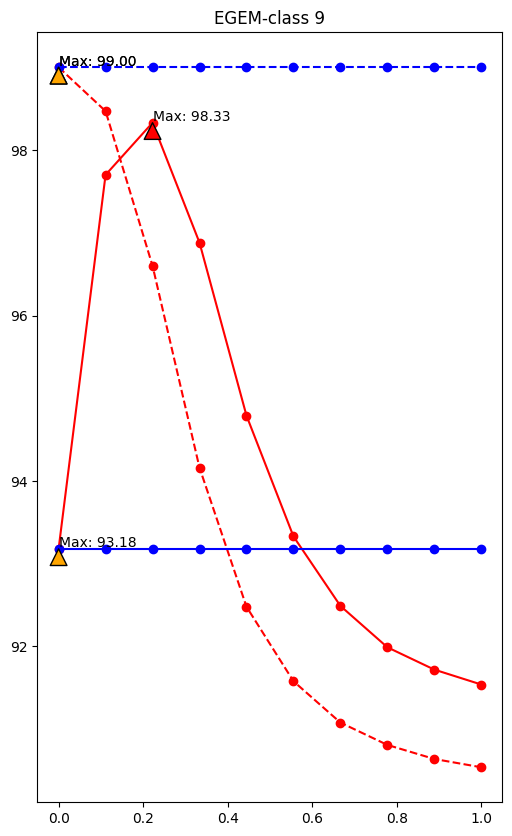

In [ ]:
fig, axe_1 = plt.subplots(figsize=(6, 10))


axe_1.plot(lambda_param_list, acc_list, linestyle='-', marker='o', color='red')
max_idx = np.argmax(acc_list)
max_val = acc_list[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='red'))


axe_1.plot(lambda_param_list, acc_list_nonpoisioned, linestyle='--', marker='o', color='red')
max_idx = np.argmax(acc_list_nonpoisioned)
max_val = acc_list_nonpoisioned[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='red'))

axe_1.plot(lambda_param_list, acc_original_poisioned_avgs, linestyle='-', marker='o', color='blue')
max_idx = np.argmax(acc_original_poisioned_avgs)
max_val = acc_original_poisioned_avgs[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='orange'))


axe_1.plot(lambda_param_list, acc_original_0poisioned_avgs, linestyle='--', marker='o', color='blue')
max_idx = np.argmax(acc_original_0poisioned_avgs)
max_val = acc_original_0poisioned_avgs[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='orange'))

axe_1.set_title("EGEM-class 9")
plt.show()

# Class-wise EGEM


## Getting Datasets

In [ ]:
#refinement_loader_list = refinement_loader_list

* Train original model
* Use refinment datasets of every class to get single class' activation values
* Calculate every class' c
* EGEM
  * forward EGEM model 10 times with c of every class
  * Construct the hybrid output
    * create an empty output_all[batch_size, 10]
    * loop 10 times from class 0 to 9
    * put the result into output_all[:, i]
  * Calculate the final accuracy

## Getting activation values

In [ ]:
'''
c_list
├── [lambda_param_0_results]
│   ├── [class_0_results]
│   │   ├── c_layer1_value (Tensor)
│   │   ├── c_layer2_value (Tensor)
│   │   ├── c_fc_value (Tensor)
│   │   └── c_fc1_value (Tensor)
│   ├── [class_1_results]
│   │   ├── c_layer1_value (Tensor)
│   │   ├── c_layer2_value (Tensor)
│   │   ├── c_fc_value (Tensor)
│   │   └── c_fc1_value (Tensor)
│   └── ... (up to num_classes)
├── [lambda_param_1_results]
│   ├── [class_0_results]
│   │   ├── c_layer1_value (Tensor)
│   │   ├── c_layer2_value (Tensor)
│   │   ├── c_fc_value (Tensor)
│   │   └── c_fc1_value (Tensor)
│   ├── ...
└── ... (up to len(lambda_param_list))
'''

'\nc_list\n├── [lambda_param_0_results]\n│   ├── [class_0_results]\n│   │   ├── c_layer1_value (Tensor)\n│   │   ├── c_layer2_value (Tensor)\n│   │   ├── c_fc_value (Tensor)\n│   │   └── c_fc1_value (Tensor)\n│   ├── [class_1_results]\n│   │   ├── c_layer1_value (Tensor)\n│   │   ├── c_layer2_value (Tensor)\n│   │   ├── c_fc_value (Tensor)\n│   │   └── c_fc1_value (Tensor)\n│   └── ... (up to num_classes)\n├── [lambda_param_1_results]\n│   ├── [class_0_results]\n│   │   ├── c_layer1_value (Tensor)\n│   │   ├── c_layer2_value (Tensor)\n│   │   ├── c_fc_value (Tensor)\n│   │   └── c_fc1_value (Tensor)\n│   ├── ...\n└── ... (up to len(lambda_param_list))\n'

In [ ]:
# Set lambda
lambda_param_s = np.linspace(0, 1, 10)
lambda_param_list = lambda_param_s.tolist()
c_list = []

for i, lambda_param in enumerate(lambda_param_list):
  c_list_per_class = []
  for j in range(num_classes):
    activation_list = get_activation_list(model, refinement_loader_list[j])

    c_layer1_value = activation_list[0]/(lambda_param + activation_list[0])
    c_layer2_value = activation_list[1]/(lambda_param + activation_list[1])
    c_fc_value = activation_list[2]/(lambda_param + activation_list[2])
    c_fc1_value = activation_list[3]/(lambda_param + activation_list[3])
    c_list_per_class.append([c_layer1_value, c_layer2_value, c_fc_value, c_fc1_value])
  c_list.append(c_list_per_class)
print("The length of c_list:{}".format(len(c_list)))

The length of c_list:10


## Adding EGEM layers

In [ ]:
#Defining the convolutional neural network
class modified_LeNet5(nn.Module):
    def __init__(self, original_model, scaling_factors_list):
        super(modified_LeNet5, self).__init__()

        # 分解 layer1 的组件
        self.conv1 = original_model.layer1[0]
        self.bn1 = original_model.layer1[1]
        self.leakyrelu1_orig = original_model.layer1[2] # LeakyReLU from layer1
        self.pool1 = original_model.layer1[3]
        self.scaler_for_leakyrelu1 = scaling_factors_list[0] # a[0]

        # 分解 layer2 的组件
        self.conv2 = original_model.layer2[0]
        self.bn2 = original_model.layer2[1]
        self.leakyrelu2_orig = original_model.layer2[2] # LeakyReLU from layer2
        self.pool2 = original_model.layer2[3]
        self.scaler_for_leakyrelu2 = scaling_factors_list[1] # a[1]

        self.fc = original_model.fc
        self.relu = original_model.relu
        self.renew = scaling_factors_list[2] # Modified layer
        self.fc1 = original_model.fc1
        self.relu1 = original_model.relu1
        self.renew_1 = scaling_factors_list[3] # Modified layer
        self.fc2 = original_model.fc2

    def forward(self, x):
        # Layer1
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.leakyrelu1_orig(out)
        out = self.pool1(out)
        # Layer2
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.leakyrelu2_orig(out)
        out = self.pool2(out)
        # Flatten
        out = out.reshape(out.size(0), -1)
        # FC
        out = self.fc(out)
        out = self.relu(out)
        out = self.fc1(out)
        out = self.relu1(out)
        out = self.fc2(out)
        return out

    def forward_EGEM(self, x):
        # Layer1
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.leakyrelu1_orig(out)
        out = out * self.scaler_for_leakyrelu1.view(1, -1, 1, 1) # Scale activiation values of Layer1
        out = self.pool1(out)
        # Layer2
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.leakyrelu2_orig(out)
        out = out * self.scaler_for_leakyrelu2.view(1, -1, 1, 1) # Scale activiation values of Layer2
        out = self.pool2(out)
        # Flatten
        out = out.reshape(out.size(0), -1)
        # FC
        out = self.fc(out)
        out = self.relu(out)
        out = out * self.renew.view(1, -1) # Scale activiation values of Fc
        out = self.fc1(out)
        out = self.relu1(out)
        out = out * self.renew_1.view(1, -1) # Scale activiation values of Fc1
        out = self.fc2(out)
        return out

## Testing per_digt EGEM model

In [ ]:
acc_original_poisioned_avgs = []
acc_original_0poisioned_avgs = []

# The results of rest classes for original model
acc_original_poisioned_avgs.append(test_model(model, test_loader))
acc_original_0poisioned_avgs.append(test_model(model, test_0poisioned_loader))

for i, lambda_param in enumerate(lambda_param_list[:-1]): # c_8
    acc_original_poisioned_avgs.append(acc_original_poisioned_avgs[0])
    acc_original_0poisioned_avgs.append(acc_original_0poisioned_avgs[0])

In [ ]:
acc_list_per_digt = []
for i in range(len(lambda_param_list)):
  # Test refined model on poisioned dataset
  acc = Accuracy(task="multiclass", num_classes=10).to(device)

  for image, label in test_loader: # Testing modified model
    image = image.to(device)
    label = label.to(device)
    with torch.no_grad():
      output_all = torch.zeros(image.size(0), num_classes, device=device)
      for j in range(num_classes):
        modified_model = modified_LeNet5(model, c_list[i][j]).to(device)
        modified_model.eval()
        output_per_digt = modified_model.forward_EGEM(image)
        output_all[:, j] = output_per_digt[:, j]
      _, predicted = torch.max(output_all.data, 1)
      acc(predicted, label)
  acc = acc.compute()
  acc = acc.item()*100
  acc_list_per_digt.append(acc)

# Test refined model on nonpoisioned dataset
acc_list_per_digt_nonpoisioned = []
for i in range(len(lambda_param_list)):
  # Test refined model on poisioned dataset
  acc = Accuracy(task="multiclass", num_classes=10).to(device)

  for image, label in test_0poisioned_loader: # Testing modified model
    image = image.to(device)
    label = label.to(device)
    with torch.no_grad():
      output_all = torch.zeros(image.size(0), num_classes, device=device)
      for j in range(num_classes):
        modified_model = modified_LeNet5(model, c_list[i][j]).to(device)
        modified_model.eval()
        output_per_digt = modified_model.forward_EGEM(image)
        output_all[:, j] = output_per_digt[:, j]
      _, predicted = torch.max(output_all.data, 1)
      acc(predicted, label)
  acc = acc.compute()
  acc = acc.item()*100
  acc_list_per_digt_nonpoisioned.append(acc)

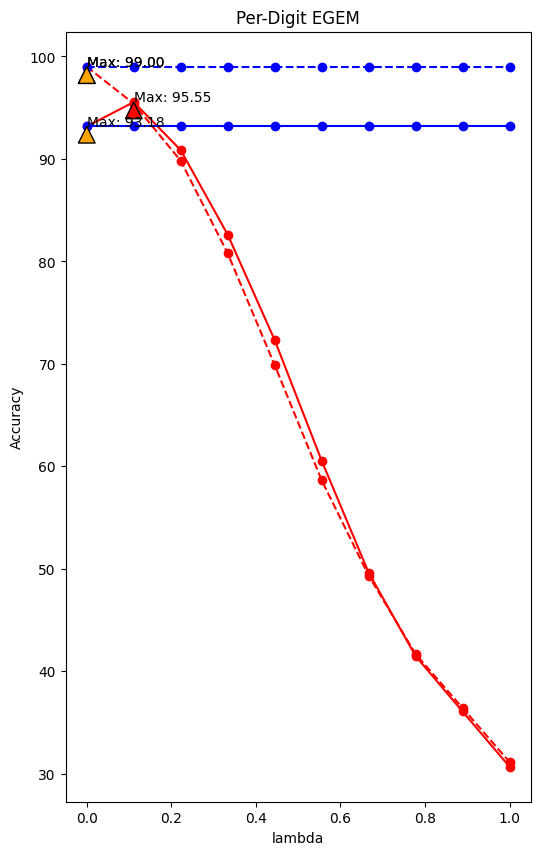

In [ ]:
fig, axe_1 = plt.subplots(figsize=(6, 10))


axe_1.plot(lambda_param_list, acc_list_per_digt, linestyle='-', marker='o', color='red')
max_idx = np.argmax(acc_list_per_digt)
max_val = acc_list_per_digt[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='red'))


axe_1.plot(lambda_param_list, acc_list_per_digt_nonpoisioned, linestyle='--', marker='o', color='red')
max_idx = np.argmax(acc_list_per_digt_nonpoisioned)
max_val = acc_list_per_digt_nonpoisioned[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='red'))

axe_1.plot(lambda_param_list, acc_original_poisioned_avgs, linestyle='-', marker='o', color='blue')
max_idx = np.argmax(acc_original_poisioned_avgs)
max_val = acc_original_poisioned_avgs[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='orange'))


axe_1.plot(lambda_param_list, acc_original_0poisioned_avgs, linestyle='--', marker='o', color='blue')
max_idx = np.argmax(acc_original_0poisioned_avgs)
max_val = acc_original_0poisioned_avgs[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='orange'))

axe_1.set_title('Per-Digit EGEM')
axe_1.set_xlabel('lambda')
axe_1.set_ylabel('Accuracy')
plt.show()

In [ ]:
acc_list_8 = []
for i in range(len(lambda_param_list)):
  # Test refined model on poisioned dataset
  acc = Accuracy(task="multiclass", num_classes=10).to(device)
  modified_model = modified_LeNet5(model, c_list[i][8]).to(device)
  modified_model.eval()

  for image, label in test_loader: # Testing modified model
    image = image.to(device)
    label = label.to(device)
    with torch.no_grad():
      output_all = modified_model.forward(image) # Getting the output from original forward
      output_8 = modified_model.forward_EGEM(image)
      output_all[:, 8] = output_8[:, 8]
      _, predicted = torch.max(output_all.data, 1)
      acc(predicted, label)
  acc = acc.compute()
  acc = acc.item()*100
  acc_list_8.append(acc)

# Test refined model on nonpoisioned dataset
acc_list_nonpoisioned_8 = []
for i in range(len(lambda_param_list)):
  acc = Accuracy(task="multiclass", num_classes=10).to(device)
  modified_model = modified_LeNet5(model, c_list[i][8]).to(device)
  modified_model.eval()

  for image, label in test_0poisioned_loader: # Testing modified model
    image = image.to(device)
    label = label.to(device)
    with torch.no_grad():
      output_all = modified_model.forward(image) # Getting the output from original forward
      output_8 = modified_model.forward_EGEM(image)
      output_all[:, 8] = output_8[:, 8]
      _, predicted = torch.max(output_all.data, 1)
      acc(predicted, label)
  acc = acc.compute()
  acc = acc.item()*100
  acc_list_nonpoisioned_8.append(acc)

In [ ]:
acc_list_0 = []
acc_list_0_nonpoisioned = []

for i in range(len(lambda_param_list)):
  modified_model = modified_LeNet5(model, c_list[i][0]).to(device)
  modified_model.eval()
  # Test refined model on poisioned dataset
  acc = Accuracy(task="multiclass", num_classes=10).to(device)
  for image, label in test_loader: # Testing modified model
    image = image.to(device)
    label = label.to(device)
    with torch.no_grad():
      output_all = modified_model.forward(image) # Getting the output from original forward
      output_8 = modified_model.forward_EGEM(image)
      output_all[:, 0] = output_8[:, 0]
      _, predicted = torch.max(output_all.data, 1)
      acc(predicted, label)
  acc = acc.compute()
  acc = acc.item()*100
  acc_list_0.append(acc)

# Test refined model on nonpoisioned dataset
for i in range(len(lambda_param_list)):
  modified_model = modified_LeNet5(model, c_list[i][0]).to(device)
  modified_model.eval()
  acc = Accuracy(task="multiclass", num_classes=10).to(device)
  for image, label in test_0poisioned_loader: # Testing modified model
    image = image.to(device)
    label = label.to(device)
    with torch.no_grad():
      output_all = modified_model.forward(image) # Getting the output from original forward
      output_8 = modified_model.forward_EGEM(image)
      output_all[:, 0] = output_8[:, 0]
      _, predicted = torch.max(output_all.data, 1)
      acc(predicted, label)
  acc = acc.compute()
  acc = acc.item()*100
  acc_list_0_nonpoisioned.append(acc)

In [ ]:
acc_list_1 = []
acc_list_1_nonpoisioned = []

for i in range(len(lambda_param_list)):
  modified_model = modified_LeNet5(model, c_list[i][1]).to(device)
  modified_model.eval()
  # Test refined model on poisioned dataset
  acc = Accuracy(task="multiclass", num_classes=10).to(device)
  for image, label in test_loader: # Testing modified model
    image = image.to(device)
    label = label.to(device)
    with torch.no_grad():
      output_all = modified_model.forward(image) # Getting the output from original forward
      output_8 = modified_model.forward_EGEM(image)
      output_all[:, 1] = output_8[:, 1]
      _, predicted = torch.max(output_all.data, 1)
      acc(predicted, label)
  acc = acc.compute()
  acc = acc.item()*100
  acc_list_1.append(acc)

# Test refined model on nonpoisioned dataset
for i in range(len(lambda_param_list)):
  modified_model = modified_LeNet5(model, c_list[i][1]).to(device)
  modified_model.eval()
  acc = Accuracy(task="multiclass", num_classes=10).to(device)

  for image, label in test_0poisioned_loader: # Testing modified model
    image = image.to(device)
    label = label.to(device)
    with torch.no_grad():
      output_all = modified_model.forward(image) # Getting the output from original forward
      output_8 = modified_model.forward_EGEM(image)
      output_all[:, 1] = output_8[:, 1]
      _, predicted = torch.max(output_all.data, 1)
      acc(predicted, label)
  acc = acc.compute()
  acc = acc.item()*100
  acc_list_1_nonpoisioned.append(acc)

In [ ]:
acc_list_9 = []
acc_list_9_nonpoisioned = []

for i in range(len(lambda_param_list)):
  modified_model = modified_LeNet5(model, c_list[i][9]).to(device)
  modified_model.eval()
  # Test refined model on poisioned dataset
  acc = Accuracy(task="multiclass", num_classes=10).to(device)
  for image, label in test_loader: # Testing modified model
    image = image.to(device)
    label = label.to(device)
    with torch.no_grad():
      output_all = modified_model.forward(image) # Getting the output from original forward
      output_8 = modified_model.forward_EGEM(image)
      output_all[:, 9] = output_8[:, 9]
      _, predicted = torch.max(output_all.data, 1)
      acc(predicted, label)
  acc = acc.compute()
  acc = acc.item()*100
  acc_list_9.append(acc)

# Test refined model on nonpoisioned dataset
for i in range(len(lambda_param_list)):
  modified_model = modified_LeNet5(model, c_list[i][9]).to(device)
  modified_model.eval()
  acc = Accuracy(task="multiclass", num_classes=10).to(device)
  for image, label in test_0poisioned_loader: # Testing modified model
    image = image.to(device)
    label = label.to(device)
    with torch.no_grad():
      output_all = modified_model.forward(image) # Getting the output from original forward
      output_8 = modified_model.forward_EGEM(image)
      output_all[:, 9] = output_8[:, 9]
      _, predicted = torch.max(output_all.data, 1)
      acc(predicted, label)
  acc = acc.compute()
  acc = acc.item()*100
  acc_list_9_nonpoisioned.append(acc)

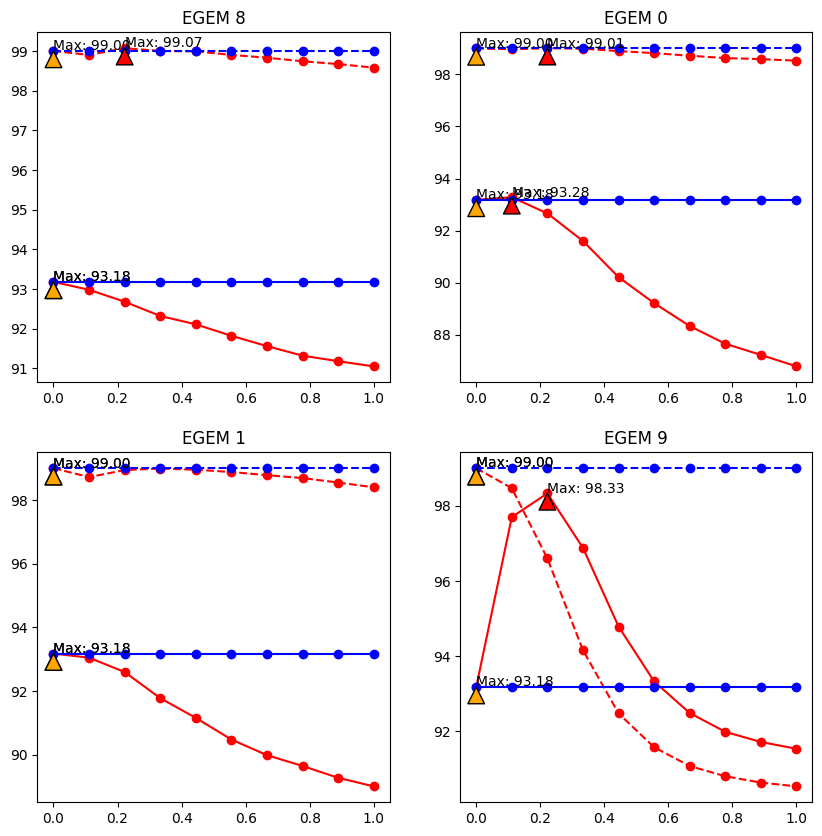

In [ ]:
fig, axes = plt.subplots(2, 2,figsize=(10, 10))


axes[0,0].plot(lambda_param_list, acc_list_8, linestyle='-', marker='o', color='red')
max_idx = np.argmax(acc_list_8)
max_val = acc_list_8[max_idx]
axes[0,0].annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='red'))


axes[0,0].plot(lambda_param_list, acc_list_nonpoisioned_8, linestyle='--', marker='o', color='red')
max_idx = np.argmax(acc_list_nonpoisioned_8)
max_val = acc_list_nonpoisioned_8[max_idx]
axes[0,0].annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='red'))

axes[0,0].plot(lambda_param_list, acc_original_poisioned_avgs, linestyle='-', marker='o', color='blue')
max_idx = np.argmax(acc_original_poisioned_avgs)
max_val = acc_original_poisioned_avgs[max_idx]
axes[0,0].annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='orange'))


axes[0,0].plot(lambda_param_list, acc_original_0poisioned_avgs, linestyle='--', marker='o', color='blue')
max_idx = np.argmax(acc_original_0poisioned_avgs)
max_val = acc_original_0poisioned_avgs[max_idx]
axes[0,0].annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='orange'))

#### EGEM 0
axes[0,1].plot(lambda_param_list, acc_list_0, linestyle='-', marker='o', color='red')
max_idx = np.argmax(acc_list_0)
max_val = acc_list_0[max_idx]
axes[0,1].annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='red'))


axes[0,1].plot(lambda_param_list, acc_list_0_nonpoisioned, linestyle='--', marker='o', color='red')
max_idx = np.argmax(acc_list_0_nonpoisioned)
max_val = acc_list_0_nonpoisioned[max_idx]
axes[0,1].annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='red'))

axes[0,1].plot(lambda_param_list, acc_original_poisioned_avgs, linestyle='-', marker='o', color='blue')
max_idx = np.argmax(acc_original_poisioned_avgs)
max_val = acc_original_poisioned_avgs[max_idx]
axes[0,1].annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='orange'))


axes[0,1].plot(lambda_param_list, acc_original_0poisioned_avgs, linestyle='--', marker='o', color='blue')
max_idx = np.argmax(acc_original_0poisioned_avgs)
max_val = acc_original_0poisioned_avgs[max_idx]
axes[0,1].annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='orange'))
#### EGEM 1
axes[1,0].plot(lambda_param_list, acc_list_1, linestyle='-', marker='o', color='red')
max_idx = np.argmax(acc_list_1)
max_val = acc_list_1[max_idx]
axes[1,0].annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='red'))


axes[1,0].plot(lambda_param_list, acc_list_1_nonpoisioned, linestyle='--', marker='o', color='red')
max_idx = np.argmax(acc_list_1_nonpoisioned)
max_val = acc_list_1_nonpoisioned[max_idx]
axes[1,0].annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='red'))

axes[1,0].plot(lambda_param_list, acc_original_poisioned_avgs, linestyle='-', marker='o', color='blue')
max_idx = np.argmax(acc_original_poisioned_avgs)
max_val = acc_original_poisioned_avgs[max_idx]
axes[1,0].annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='orange'))


axes[1,0].plot(lambda_param_list, acc_original_0poisioned_avgs, linestyle='--', marker='o', color='blue')
max_idx = np.argmax(acc_original_0poisioned_avgs)
max_val = acc_original_0poisioned_avgs[max_idx]
axes[1,0].annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='orange'))

#### EGEM 9
axes[1,1].plot(lambda_param_list, acc_list_9, linestyle='-', marker='o', color='red')
max_idx = np.argmax(acc_list_9)
max_val = acc_list_9[max_idx]
axes[1,1].annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='red'))


axes[1,1].plot(lambda_param_list, acc_list_9_nonpoisioned, linestyle='--', marker='o', color='red')
max_idx = np.argmax(acc_list_9_nonpoisioned)
max_val = acc_list_9_nonpoisioned[max_idx]
axes[1,1].annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='red'))

axes[1,1].plot(lambda_param_list, acc_original_poisioned_avgs, linestyle='-', marker='o', color='blue')
max_idx = np.argmax(acc_original_poisioned_avgs)
max_val = acc_original_poisioned_avgs[max_idx]
axes[1,1].annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='orange'))


axes[1,1].plot(lambda_param_list, acc_original_0poisioned_avgs, linestyle='--', marker='o', color='blue')
max_idx = np.argmax(acc_original_0poisioned_avgs)
max_val = acc_original_0poisioned_avgs[max_idx]
axes[1,1].annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='orange'))

axes[0, 0].set_title('EGEM 8')
axes[0, 1].set_title('EGEM 0')
axes[1, 0].set_title('EGEM 1')
axes[1, 1].set_title('EGEM 9')
plt.show()

## Correct the model

Right now the result of CEGEM is not expected and not better than original EGEM. We need to do some experiences to find out problems and fix them.

### Method 1: Adapted to every forward's output value.

This experienment aims to try if the outputs of every forward in CEGEM model on the same level, excatly if the minimal value of a class' output still greater than the maximal value of the other class', it will impact the final prediction of CEGEM. So we need a method to adapt to those outputs.

In [ ]:
output_EGEM_scaling_factor_list = []

for i in range(len(lambda_param_list)):
  output_original_list = []
  output_refined_list = []
  # Test refined model on poisioned dataset
  for image, label in refinement_loader: # Testing modified model
    image = image.to(device)
    label = label.to(device)
    with torch.no_grad():
      # Get output from original model
      output = model(image)
      # Get output from refined model
      output_all = torch.zeros(image.size(0), num_classes, device=device)
      for j in range(num_classes):
        modified_model = modified_LeNet5(model, c_list[i][j]).to(device)
        modified_model.eval()
        output_per_digt = modified_model.forward_EGEM(image)
        output_all[:, j] = output_per_digt[:, j]
      output_original_list.append(output)
      output_refined_list.append(output_all)

  # Get original model output mean list
  output_original_list = torch.cat(output_original_list, dim=0)
  output_mean_original_model = torch.mean(output_original_list,dim=0)
  output_mean_original_model = abs(output_mean_original_model)
  # Get EGEM output mean list
  output_refined_list = torch.cat(output_refined_list, dim=0)
  output_mean_EGEM = abs(torch.mean(output_refined_list, dim=0))

  # Calculate scaling factors
  output_EGEM_scaling_factor = output_mean_original_model / output_mean_EGEM
  output_EGEM_scaling_factor_list.append(output_EGEM_scaling_factor)

* output_original_model_mean_list
* output_EGEM_mean_list

In [ ]:
def zscore_normalize(arr):
    # Use PyTorch operations instead of NumPy
    mean = torch.mean(arr)
    std = torch.std(arr)
    return (arr - mean) / std

In [ ]:
acc_list_per_digt = []
for i in range(len(lambda_param_list)):
  # Test refined model on poisioned dataset
  acc = Accuracy(task="multiclass", num_classes=10).to(device)

  for image, label in test_loader: # Testing modified model
    image = image.to(device)
    label = label.to(device)
    with torch.no_grad():
      output_all = torch.zeros(image.size(0), num_classes, device=device)
      for j in range(num_classes):
        modified_model = modified_LeNet5(model, c_list[i][j]).to(device)
        modified_model.eval()
        output_per_digt = modified_model.forward_EGEM(image)
        output_all[:, j] = output_per_digt[:, j]
      output_all = output_all * output_EGEM_scaling_factor_list[i] # add scaling factors
      _, predicted = torch.max(output_all.data, 1)
      acc(predicted, label)
  acc = acc.compute()
  acc = acc.item()*100
  acc_list_per_digt.append(acc)

# Test refined model on nonpoisioned dataset
acc_list_per_digt_nonpoisioned = []
for i in range(len(lambda_param_list)):
  # Test refined model on poisioned dataset
  acc = Accuracy(task="multiclass", num_classes=10).to(device)

  for image, label in test_0poisioned_loader: # Testing modified model
    image = image.to(device)
    label = label.to(device)
    with torch.no_grad():
      output_all = torch.zeros(image.size(0), num_classes, device=device)
      for j in range(num_classes):
        modified_model = modified_LeNet5(model, c_list[i][j]).to(device)
        modified_model.eval()
        output_per_digt = modified_model.forward_EGEM(image)
        output_all[:, j] = output_per_digt[:, j]
    output_all = output_all * output_EGEM_scaling_factor_list[i] # add scaling factors
    _, predicted = torch.max(output_all.data, 1)
    acc(predicted, label)
  acc = acc.compute()
  acc = acc.item()*100
  acc_list_per_digt_nonpoisioned.append(acc)

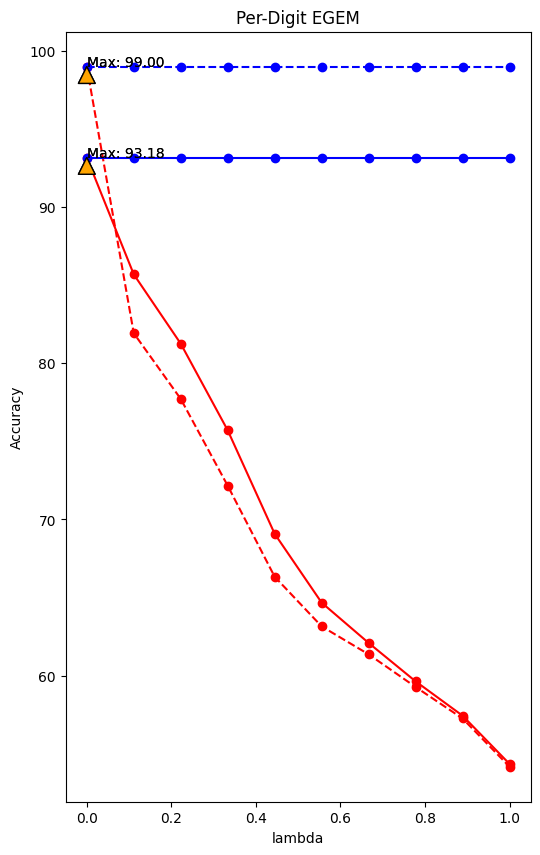

In [ ]:
fig, axe_1 = plt.subplots(figsize=(6, 10))


axe_1.plot(lambda_param_list, acc_list_per_digt, linestyle='-', marker='o', color='red')
max_idx = np.argmax(acc_list_per_digt)
max_val = acc_list_per_digt[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='red'))


axe_1.plot(lambda_param_list, acc_list_per_digt_nonpoisioned, linestyle='--', marker='o', color='red')
max_idx = np.argmax(acc_list_per_digt_nonpoisioned)
max_val = acc_list_per_digt_nonpoisioned[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='red'))

axe_1.plot(lambda_param_list, acc_original_poisioned_avgs, linestyle='-', marker='o', color='blue')
max_idx = np.argmax(acc_original_poisioned_avgs)
max_val = acc_original_poisioned_avgs[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='orange'))


axe_1.plot(lambda_param_list, acc_original_0poisioned_avgs, linestyle='--', marker='o', color='blue')
max_idx = np.argmax(acc_original_0poisioned_avgs)
max_val = acc_original_0poisioned_avgs[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='orange'))

axe_1.set_title('Per-Digit EGEM')
axe_1.set_xlabel('lambda')
axe_1.set_ylabel('Accuracy')
plt.show()

### Method 2: Normalization

In [ ]:
def zscore_normalize(arr):
    # Use PyTorch operations instead of NumPy
    mean = torch.mean(arr)
    std = torch.std(arr)
    return (arr - mean) / std

In [ ]:
acc_list_per_digt = []
for i in range(len(lambda_param_list)):
  # Test refined model on poisioned dataset
  acc = Accuracy(task="multiclass", num_classes=10).to(device)

  for image, label in test_loader: # Testing modified model
    image = image.to(device)
    label = label.to(device)
    with torch.no_grad():
      output_all = torch.zeros(image.size(0), num_classes, device=device)
      for j in range(num_classes):
        modified_model = modified_LeNet5(model, c_list[i][j]).to(device)
        modified_model.eval()
        output_per_digt = modified_model.forward_EGEM(image)

        # Normalization the output in order to control the output strength on the same level
        output_per_digt = zscore_normalize(output_per_digt)
        #

        output_all[:, j] = output_per_digt[:, j]
      _, predicted = torch.max(output_all.data, 1)
      acc(predicted, label)
  acc = acc.compute()
  acc = acc.item()*100
  acc_list_per_digt.append(acc)

# Test refined model on nonpoisioned dataset
acc_list_per_digt_nonpoisioned = []
for i in range(len(lambda_param_list)):
  # Test refined model on poisioned dataset
  acc = Accuracy(task="multiclass", num_classes=10).to(device)

  for image, label in test_0poisioned_loader: # Testing modified model
    image = image.to(device)
    label = label.to(device)
    with torch.no_grad():
      output_all = torch.zeros(image.size(0), num_classes, device=device) # Get an empty output
      for j in range(num_classes):
        modified_model = modified_LeNet5(model, c_list[i][j]).to(device) # Get refined model
        modified_model.eval()
        output_per_digt = modified_model.forward_EGEM(image) # Gernerate each class' EGEM output

        # Normalization the output in order to control the output strength on the same level
        output_per_digt = zscore_normalize(output_per_digt)
        #

        output_all[:, j] = output_per_digt[:, j] # Merge outputs together
      _, predicted = torch.max(output_all.data, 1)
      acc(predicted, label)
  acc = acc.compute()
  acc = acc.item()*100
  acc_list_per_digt_nonpoisioned.append(acc)

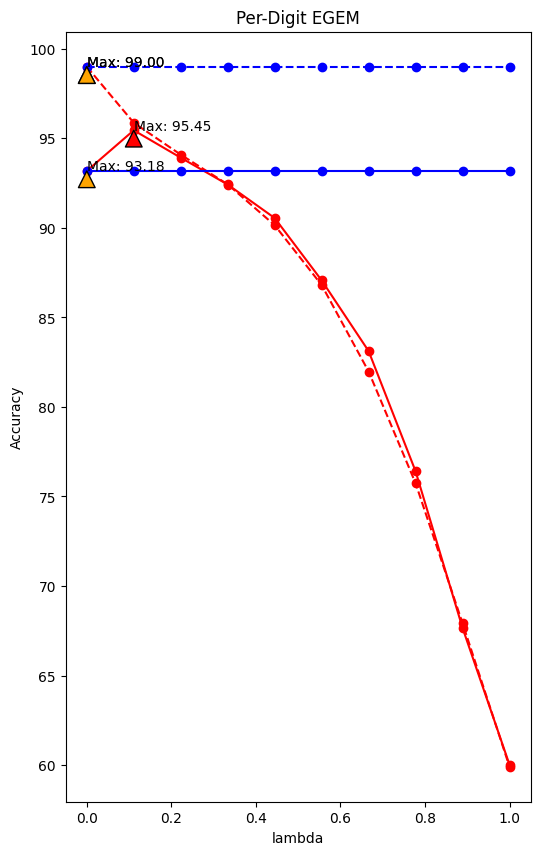

In [ ]:
fig, axe_1 = plt.subplots(figsize=(6, 10))


axe_1.plot(lambda_param_list, acc_list_per_digt, linestyle='-', marker='o', color='red')
max_idx = np.argmax(acc_list_per_digt)
max_val = acc_list_per_digt[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='red'))


axe_1.plot(lambda_param_list, acc_list_per_digt_nonpoisioned, linestyle='--', marker='o', color='red')
max_idx = np.argmax(acc_list_per_digt_nonpoisioned)
max_val = acc_list_per_digt_nonpoisioned[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='red'))

axe_1.plot(lambda_param_list, acc_original_poisioned_avgs, linestyle='-', marker='o', color='blue')
max_idx = np.argmax(acc_original_poisioned_avgs)
max_val = acc_original_poisioned_avgs[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='orange'))


axe_1.plot(lambda_param_list, acc_original_0poisioned_avgs, linestyle='--', marker='o', color='blue')
max_idx = np.argmax(acc_original_0poisioned_avgs)
max_val = acc_original_0poisioned_avgs[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='orange'))

axe_1.set_title('Per-Digit EGEM')
axe_1.set_xlabel('lambda')
axe_1.set_ylabel('Accuracy')
plt.show()